<a href="https://colab.research.google.com/github/LaurenMitchell-tech/uvvisml/blob/main/CIE_Color_Plot_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

if os.getenv("COLAB_RELEASE_TAG"):
    try:
        import chemprop
    except ImportError:
        !git clone https://github.com/chemprop/chemprop.git
        %cd chemprop
        !pip install .

os.chdir('/content')
!git clone https://github.com/learningmatter-mit/uvvisml
os.chdir('/content/uvvisml/uvvisml')

Cloning into 'chemprop'...
remote: Enumerating objects: 25475, done.
remote: Counting objects: 100% (220/220), done.
remote: Compressing objects: 100% (174/174), done.
remote: Total 25475 (delta 131), reused 46 (delta 46), pack-reused 25255 (from 4)
Receiving objects: 100% (25475/25475), 876.92 MiB | 29.36 MiB/s, done.
Resolving deltas: 100% (18263/18263), done.
Updating files: 100% (337/337), done.
/content/chemprop
Processing /content/chemprop
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 66.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/colour/utilities/verbose.py:340: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)


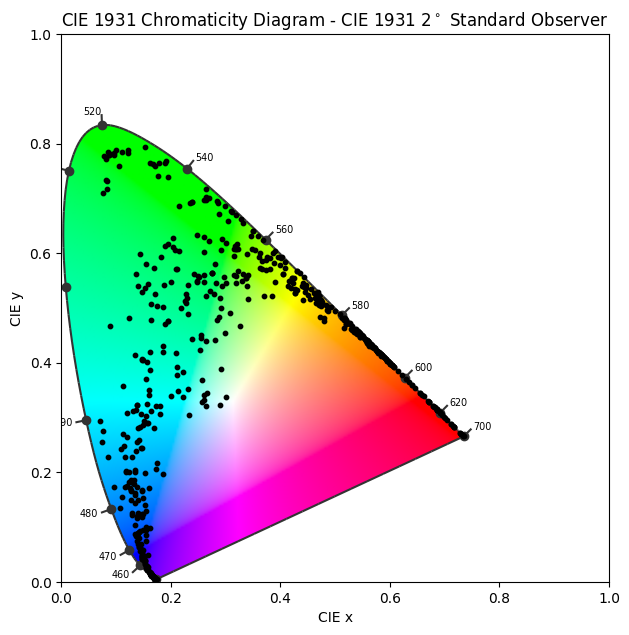

In [ ]:
# ============================================================
# Multi-spectrum CIE 1931 chromaticity plot using
# Gaussian spectra defined in wavenumber space
# ============================================================

!pip install colour-science pandas --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import colour
import math

# ---- Step 1: Load centers and bandwidths from CSV

csv_file = "data/original/joung/DB_for_chromophore_Sci_Data_rev02.csv"
data = pd.read_csv(csv_file, usecols=["Tag", "Emission max (nm)", "emi FWHM (cm-1)"])

# ---- Step 2: Build spectra from formula ----
wavelengths = np.linspace(380, 780, 401)  # nanometers

spectra = {}
for _, row in data.iterrows():
    try:
        name = str(row["Tag"])
        L = float(row["Emission max (nm)"])
        S = float(row["emi FWHM (cm-1)"])

        # Skip invalid rows
        if np.isnan(L) or np.isnan(S) or S == 0:
            continue

        intensities = [
            math.exp(-4 * math.log(2) * (((1e7 / W) - (1e7 / L)) / S) ** 2)
            for W in wavelengths
        ]

        spectra[name] = colour.SpectralDistribution(dict(zip(wavelengths, intensities)), name=name)
    except:
        continue

# ---- Step 3: Define CMFs and Illuminant ----
cmfs = colour.MSDS_CMFS["CIE 1931 2 Degree Standard Observer"]
illuminant = colour.SDS_ILLUMINANTS["D65"]

# ---- Step 4: Compute XYZ and xyY for each spectrum ----
results = {}
for name, spectrum in spectra.items():
    XYZ = colour.sd_to_XYZ(spectrum, cmfs=cmfs, illuminant=illuminant)
    xyY = colour.XYZ_to_xyY(XYZ)
    results[name] = {"XYZ": XYZ, "xyY": xyY}

# ---- Step 5: Plot CIE 1931 diagram ----
colour.plotting.plot_chromaticity_diagram_CIE1931(standalone=False)

# ---- Step 6: Plot points as black dots ----
for name, data in results.items():
    x, y = float(data["xyY"][0]), float(data["xyY"][1])
    if 0 <= x <= 0.8 and 0 <= y <= 0.9:
      plt.scatter([x], [y], color="black", s=10, zorder=10)
      #plt.text(x + 0.01, y + 0.01, name, fontsize=10, color="black")

plt.show()